# Retained model: a leak-safe sparse logistic pipeline

### From the EDA constraints to one reproducible classifier

This notebook answers four questions:

1. What information enters the retained model?
2. Where is each preprocessing step learned?
3. How stable and calibrated are the out-of-fold predictions?
4. What is fitted before producing the final test probabilities?

The objective is a transparent benchmark, not an exhaustive model search. Every
performance number below comes from validation folds that keep complete `TS`
groups together.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import set_config

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cross_validation import CVConfig, ModelConfig, run_cv
from src.data import ChallengeDataLoader
from src.metrics import build_validation_report
from src.models import MODEL_FEATURES, make_baseline_v2

COLORS = {
    "ink": "#183446",
    "model": "#2A9D8F",
    "accent": "#E76F51",
    "gold": "#E9C46A",
    "muted": "#8A99A6",
    "grid": "#DCE4E8",
}
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05,
    rc={
        "axes.edgecolor": COLORS["grid"],
        "axes.labelcolor": COLORS["ink"],
        "axes.titlecolor": COLORS["ink"],
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.65,
    },
)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120})
set_config(display="diagram")

X_train = ChallengeDataLoader.load_X_train()
y_train = ChallengeDataLoader.load_y_train()
X_test = ChallengeDataLoader.load_X_test()
sample_submission = ChallengeDataLoader.load_sample_submission()

## 1. Model in one view

The pipeline has a deliberately small surface:

| Block | Operation | Learned inside each fold? |
|---|---|---:|
| Returns | Median imputation and standardization of eight selected lags | Yes |
| Fixed effects | One-hot encoding of `ALLOCATION` and `GROUP` | Yes |
| Heterogeneous slope | Standardized `RET_1` interacted with allocation indicators | Yes |
| Classifier | L2-regularized logistic regression (`C=0.003`) | Yes |

The implementation uses a standard `ColumnTransformer`. The only custom block
is the allocation-specific `RET_1` interaction, because that transformation is
specific to this model rather than generic preprocessing.

No date ordering, target encoding, or reconstructed rolling window enters the
estimator.

In [2]:
pipeline = make_baseline_v2()
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('returns',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RET_1', 'RET_2', 'RET_3',
                                                   'RET_4', 'RET_7', 'RET_8',
                                                   'RET_9', 'RET_18']),
                                                 ('fixed_effects',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ALLOCATION', 'GROUP']),
                                                 ('allocation_ret1',
                                                  AllocationReturnInteraction(),
                                                  ['ALLOCATION', 'RET_1'])],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 LogisticRegression(C=0.003, max_iter=150, random_state=0,
                                    tol=1e-05))])

## 2. Date-grouped validation

The split is performed on unique dates, not on rows. For each of the eight
folds, scikit-learn clones the complete pipeline and learns imputation,
standardization, category levels, interactions, and coefficients using only the
training dates.

The folds are shuffled reproducibly with `random_state=0`. Their identifiers
are labels, not a chronological sequence.

In [3]:
cv_result = run_cv(
    X_train,
    y_train,
    ModelConfig(model=pipeline, features=list(MODEL_FEATURES)),
    CVConfig(n_splits=8, shuffle=True, random_state=0),
)
oof = cv_result.oof_results
report = build_validation_report(oof)

headline = pd.DataFrame(
    {
        "metric": [
            "OOF accuracy",
            "Balanced accuracy",
            "ROC AUC",
            "Brier score",
            "Expected calibration error",
            "Observed positive rate",
            "Predicted positive rate",
        ],
        "value": [
            report["classification"]["accuracy"],
            report["classification"]["balanced_accuracy"],
            report["classification"]["auc"],
            report["classification"]["brier"],
            report["calibration"]["ece"],
            report["classification"]["target_positive_rate"],
            report["classification"]["prediction_positive_rate"],
        ],
    }
)
headline.style.hide(axis="index").format({"value": "{:.3%}"}).set_caption(
    "Out-of-fold classification summary"
)

metric,value
OOF accuracy,52.500%
Balanced accuracy,52.348%
ROC AUC,53.522%
Brier score,24.893%
Expected calibration error,0.210%
Observed positive rate,50.718%
Predicted positive rate,60.603%


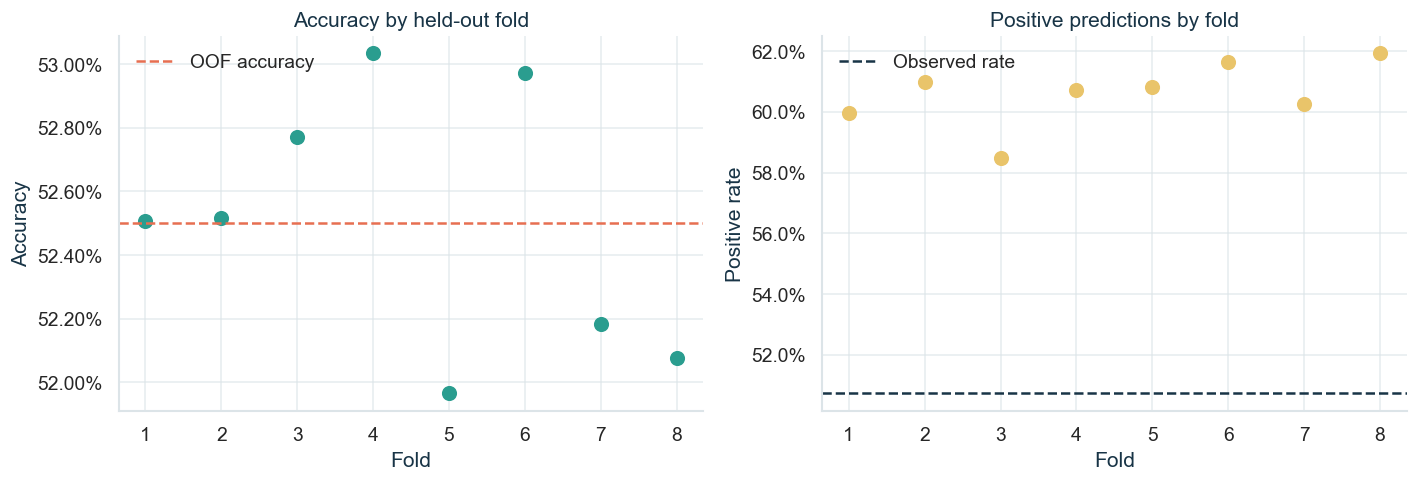

fold,validation rows,accuracy,balanced accuracy,predicted positive rate
1,"65,998",52.51%,52.31%,59.96%
2,"66,349",52.51%,52.30%,60.99%
3,"64,972",52.77%,52.51%,58.48%
4,"64,565",53.03%,52.89%,60.71%
5,"67,413",51.96%,51.84%,60.83%
6,"66,229",52.97%,52.82%,61.65%
7,"66,209",52.18%,52.11%,60.25%
8,"65,338",52.08%,52.08%,61.93%


In [4]:
fold_metrics = pd.DataFrame(
    [
        {
            "fold": fold.fold_id,
            "validation rows": int(fold.valid_index.sum()),
            "accuracy": fold.valid_metrics["accuracy"],
            "balanced accuracy": fold.valid_metrics["balanced_accuracy"],
            "predicted positive rate": fold.valid_metrics["prediction_positive_rate"],
        }
        for fold in cv_result.fold_results
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(fold_metrics["fold"], fold_metrics["accuracy"], s=65, color=COLORS["model"])
axes[0].axhline(cv_result.mean_accuracy, color=COLORS["accent"], linestyle="--", label="OOF accuracy")
axes[0].set(title="Accuracy by held-out fold", xlabel="Fold", ylabel="Accuracy")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(frameon=False)

target_rate = y_train["target_binarized"].mean()
axes[1].scatter(
    fold_metrics["fold"],
    fold_metrics["predicted positive rate"],
    s=65,
    color=COLORS["gold"],
)
axes[1].axhline(target_rate, color=COLORS["ink"], linestyle="--", label="Observed rate")
axes[1].set(title="Positive predictions by fold", xlabel="Fold", ylabel="Positive rate")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

fold_metrics.style.hide(axis="index").format(
    {
        "validation rows": "{:,.0f}",
        "accuracy": "{:.2%}",
        "balanced accuracy": "{:.2%}",
        "predicted positive rate": "{:.2%}",
    }
).set_caption("Fold-level diagnostics")

> **Result.** OOF accuracy is **52.50%**, and every fold lies between
> **51.96%** and **53.03%**. The model predicts the positive class for **60.60%**
> of rows, compared with an observed positive rate of **50.72%**. Accuracy alone
> is therefore insufficient: probability calibration and group stability must
> be inspected as well.

## 3. Calibration and group stability

The reliability plot compares mean predicted probability with the empirical
positive rate in each occupied probability bin. Marker size represents the
number of observations, so sparse extreme bins do not receive the same visual
weight as the dense central bins.

The stability table reports the distribution of accuracy across dates and
allocations. These summaries describe where performance varies; they are not
econometric standard errors under panel dependence.

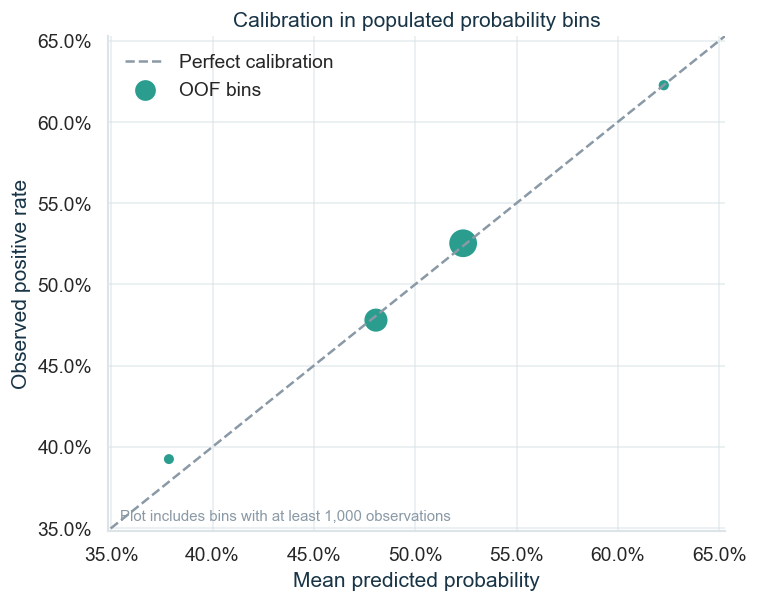

bin,n,mean_probability,positive_rate,absolute_gap
1,1,19.54%,0.00%,19.54%
2,57,27.31%,40.35%,13.04%
3,"1,404",37.85%,39.25%,1.39%
4,"206,189",48.06%,47.80%,0.27%
5,"315,321",52.37%,52.53%,0.16%
6,"3,985",62.27%,62.26%,0.01%
7,106,73.36%,64.15%,9.21%
8,10,82.48%,60.00%,22.48%


In [5]:
calibration = report["calibration"]["table"].copy()
plot_calibration = calibration.loc[calibration["n"] >= 1_000].copy()
marker_size = 45 + 260 * plot_calibration["n"] / plot_calibration["n"].max()

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ax.plot([0, 1], [0, 1], color=COLORS["muted"], linestyle="--", label="Perfect calibration")
ax.scatter(
    plot_calibration["mean_probability"],
    plot_calibration["positive_rate"],
    s=marker_size,
    color=COLORS["model"],
    edgecolor="white",
    linewidth=0.8,
    label="OOF bins",
)
central_low = min(plot_calibration["mean_probability"].min(), plot_calibration["positive_rate"].min()) - 0.03
central_high = max(plot_calibration["mean_probability"].max(), plot_calibration["positive_rate"].max()) + 0.03
ax.set(
    title="Calibration in populated probability bins",
    xlabel="Mean predicted probability",
    ylabel="Observed positive rate",
    xlim=(max(0, central_low), min(1, central_high)),
    ylim=(max(0, central_low), min(1, central_high)),
)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)
ax.text(
    0.02,
    0.02,
    "Plot includes bins with at least 1,000 observations",
    transform=ax.transAxes,
    color=COLORS["muted"],
    fontsize=9,
)
plt.tight_layout()
plt.show()

calibration.style.hide(axis="index").format(
    {
        "n": "{:,.0f}",
        "mean_probability": "{:.2%}",
        "positive_rate": "{:.2%}",
        "absolute_gap": "{:.2%}",
    }
).set_caption("Occupied calibration bins")

In [6]:
stability_rows = []
for label, column in [("Date", "TS"), ("Allocation", "ALLOCATION")]:
    accuracy = oof.groupby(column, observed=True)["is_correct"].mean()
    stability_rows.append(
        {
            "level": label,
            "groups": len(accuracy),
            "5th percentile": accuracy.quantile(0.05),
            "median": accuracy.median(),
            "95th percentile": accuracy.quantile(0.95),
            "standard deviation": accuracy.std(),
        }
    )

stability = pd.DataFrame(stability_rows)
stability.style.hide(axis="index").format(
    {
        "groups": "{:,.0f}",
        "5th percentile": "{:.2%}",
        "median": "{:.2%}",
        "95th percentile": "{:.2%}",
        "standard deviation": "{:.2%}",
    }
).set_caption("Distribution of group-level OOF accuracy")

level,groups,5th percentile,median,95th percentile,standard deviation
Date,"2,522",39.49%,52.90%,67.16%,8.62%
Allocation,278,49.62%,52.40%,55.37%,2.26%


> **Result.** The overall expected calibration error is **0.21
> percentage points**. Most observations receive probabilities between 40% and
> 60%; estimates in the extreme bins are based on very few rows and should not
> be overinterpreted.
>
> Allocation accuracy is relatively concentrated: its 5th to 95th percentile
> range is approximately **49.62%–55.37%**. Date accuracy is much wider
> (**39.49%–67.16%**), consistent with smaller date-level samples and common
> cross-sectional movements. A separate simulation study is required before
> attaching inferential meaning to this dispersion.

## 4. Model interpretation and final fit

For a linear classifier, a useful descriptive ranking is the standard deviation
of each feature's fitted contribution, `|coefficient| × feature standard
deviation`. This puts continuous variables, sparse fixed effects, and
allocation-specific slopes on a more comparable scale.

The ranking describes the fitted prediction rule. It does not identify causal
effects and it should not be read as a feature-selection test.

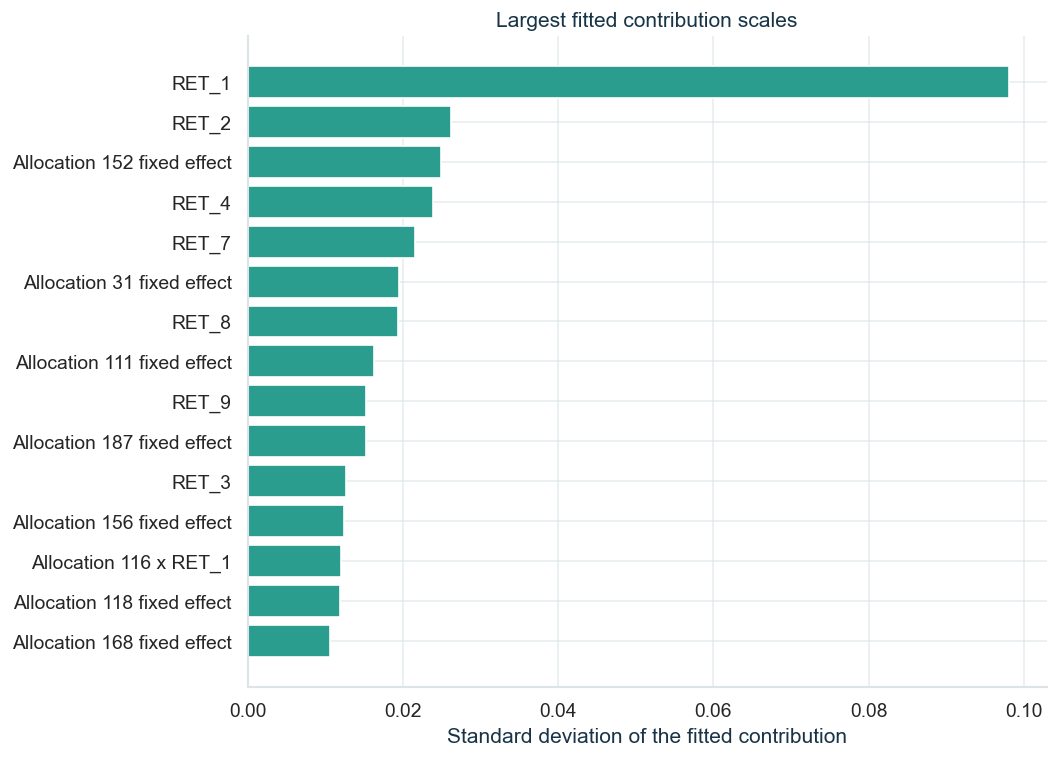

display feature,coefficient,contribution standard deviation
RET_1,0.0980,0.0980
RET_2,-0.0263,0.0263
Allocation 152 fixed effect,0.3668,0.0249
RET_4,-0.0238,0.0238
RET_7,0.0215,0.0215
Allocation 31 fixed effect,0.3280,0.0195
RET_8,0.0194,0.0194
Allocation 111 fixed effect,-0.2744,0.0163
RET_9,0.0153,0.0153
Allocation 187 fixed effect,0.2521,0.0152


In [7]:
fitted_pipeline = make_baseline_v2().fit(X_train, y_train["target_binarized"])
preprocessor = fitted_pipeline.named_steps["preprocessor"]
classifier = fitted_pipeline.named_steps["classifier"]
design_matrix = preprocessor.transform(X_train)

feature_mean = np.asarray(design_matrix.mean(axis=0)).ravel()
feature_second_moment = np.asarray(design_matrix.power(2).mean(axis=0)).ravel()
feature_std = np.sqrt(np.maximum(feature_second_moment - feature_mean**2, 0.0))
importance = pd.DataFrame(
    {
        "feature": preprocessor.get_feature_names_out(),
        "coefficient": classifier.coef_.ravel(),
        "contribution standard deviation": np.abs(classifier.coef_.ravel()) * feature_std,
    }
).sort_values("contribution standard deviation", ascending=False)


def readable_feature_name(name):
    if name.startswith("ALLOCATION_ALLOCATION_"):
        label = name.removeprefix("ALLOCATION_ALLOCATION_")
        return f"Allocation {label}" if " x RET_1" in label else f"Allocation {label} fixed effect"
    if name.startswith("GROUP_GROUP_"):
        return f"Group {name.removeprefix('GROUP_GROUP_')} fixed effect"
    return name


importance["display feature"] = importance["feature"].map(readable_feature_name)

top = importance.head(15).sort_values("contribution standard deviation")
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top["display feature"], top["contribution standard deviation"], color=COLORS["model"])
ax.set(
    title="Largest fitted contribution scales",
    xlabel="Standard deviation of the fitted contribution",
    ylabel="",
)
plt.tight_layout()
plt.show()

importance.head(15)[["display feature", "coefficient", "contribution standard deviation"]].style.hide(axis="index").format(
    {"coefficient": "{:.4f}", "contribution standard deviation": "{:.4f}"}
).set_caption("Top individual fitted contributions")

In [8]:
test_probability = fitted_pipeline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability > 0.5).astype(int)

submission_check = pd.DataFrame(
    {
        "check": [
            "Test rows",
            "Index aligned with sample submission",
            "Missing probabilities",
            "Minimum probability",
            "Maximum probability",
            "Positive prediction rate",
        ],
        "value": [
            f"{len(test_probability):,}",
            "PASS" if X_test.index.equals(sample_submission.index) else "FAIL",
            f"{int(pd.isna(test_probability).sum()):,}",
            f"{test_probability.min():.2%}",
            f"{test_probability.max():.2%}",
            f"{test_prediction.mean():.2%}",
        ],
    }
)
submission_check.style.hide(axis="index").set_caption("Final-fit submission checks")

check,value
Test rows,"31,870"
Index aligned with sample submission,PASS
Missing probabilities,0
Minimum probability,27.10%
Maximum probability,86.84%
Positive prediction rate,60.23%


## 5. What is retained

| Decision | Rationale |
|---|---|
| Keep the complete scikit-learn pipeline | Every learned transformation is refitted within each validation fold. |
| Keep the sparse linear classifier | It provides a transparent improvement over the elementary benchmark at low complexity. |
| Keep allocation-specific `RET_1` slopes | They allow the clearest elementary signal to vary across allocations. |
| Report calibration and positive rates with accuracy | A 0.5 threshold produces materially more positive predictions than the sample prevalence. |
| Treat date dispersion as descriptive | Panel-dependent inference belongs to the dedicated simulation study. |

The canonical estimator is `src.models.make_baseline_v2`; date-grouped
validation is implemented by `src.cross_validation.run_cv`. The next notebook
compares this retained model with the supplied QRT baseline on identical folds.